In [ ]:
import os, glob, warnings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings("ignore")

import eval_common as _ec
_ec.set_axis("mechanism")
AXIS = _ec.AXIS
OUT  = _ec.OUTPUT_DIR
print("AXIS =", AXIS)
print("OUTPUT_DIR =", OUT)

FIGDIR = OUT / "comparison_figures"
FIGDIR.mkdir(exist_ok=True, parents=True)

AXIS = mechanism
OUTPUT_DIR = model_outputs


In [ ]:

pred_files = sorted(glob.glob(str(OUT / f"predictions_*_{AXIS}.csv")))
assert pred_files, f"No predictions_*_{AXIS}.csv found in {OUT} - run the models first."
print(f"{len(pred_files)} prediction files:")
for f in pred_files: print("  ", os.path.basename(f))

sample = pd.read_csv(pred_files[0])
print("\ncolumns in sample:", list(sample.columns))


PERIOD = "month_period" if "month_period" in sample.columns else \
         ("quarter_period" if "quarter_period" in sample.columns else None)
if PERIOD is None:  # last resort: anything ending in _period
    cand = [c for c in sample.columns if c.endswith("period")]
    PERIOD = cand[0] if cand else None
assert PERIOD, "Could not find a period column."

STRUCTURAL = {PERIOD, "test_year", "actual_count", "predicted_share",
              "predicted_count", "actual_share", "model", "axis"}
cat_candidates = [c for c in sample.columns
                  if c not in STRUCTURAL and sample[c].dtype == object]
for pref in ("category", AXIS, "mechanism", "lob", "risk_peril", "line_of_business"):
    if pref in sample.columns:
        CATEGORY = pref; break
else:
    CATEGORY = cat_candidates[0] if cat_candidates else None
assert CATEGORY, f"Could not detect category column among {list(sample.columns)}"

print(f"\nDetected -> PERIOD={PERIOD!r}  CATEGORY={CATEGORY!r}")

ORDER = None
for attr in ("MECH_ORDER" if AXIS=="mechanism" else "LOB_ORDER", "CATEGORY_ORDER", "ORDER"):
    if hasattr(_ec, attr):
        ORDER = list(getattr(_ec, attr)); break
if ORDER is None:
    ORDER = sorted(sample[CATEGORY].dropna().unique())
print("categories:", ORDER)

7 prediction files:
   predictions_catboost_baseline_tuned_mechanism.csv
   predictions_compositional_hawkes_mechanism.csv
   predictions_dynamic_baseline_marked_hawkes_mechanism.csv
   predictions_multitask_elastic_net_tuned_mechanism.csv
   predictions_poisson_mechanism.csv
   predictions_regularised_marked_hawkes_tuned_mechanism.csv
   predictions_static_mechanism.csv

columns in sample: ['model', 'fold', 'month_period', 'category', 'actual_count', 'actual_share', 'predicted_share']

Detected -> PERIOD='month_period'  CATEGORY='category'
categories: ['Reliability', 'Bias & Fairness', 'Privacy, Confidentiality & Infringement', 'Security & Misuse', 'Autonomous Actions', 'Governance, Oversight & Explainability']


In [ ]:
def model_name(path):
    return os.path.basename(path).replace("predictions_", "").replace(f"_{AXIS}.csv", "")

frames = []
for f in pred_files:
    d = pd.read_csv(f)
    d["model"] = model_name(f)
    frames.append(d)
pred = pd.concat(frames, ignore_index=True)

FOLDKEY = "test_year" if "test_year" in pred.columns else "fold"
grp = ["model", FOLDKEY, PERIOD]
pred["period_total"] = pred.groupby(grp)["actual_count"].transform("sum")
pred["actual_share"] = np.where(pred["period_total"] > 0,
                                pred["actual_count"] / pred["period_total"], np.nan)

pred[CATEGORY] = pd.Categorical(pred[CATEGORY], categories=ORDER, ordered=True)

pred["t"] = pred[FOLDKEY].astype(str) + "-" + pred[PERIOD].astype(str)
models = sorted(pred["model"].unique())
print(f"{len(pred):,} rows · {len(models)} models · {pred[CATEGORY].nunique()} categories")
print("models:", models)

3,276 rows · 7 models · 6 categories
models: ['catboost_baseline_tuned', 'compositional_hawkes', 'dynamic_baseline_marked_hawkes', 'multitask_elastic_net_tuned', 'poisson', 'regularised_marked_hawkes_tuned', 'static']


In [10]:
# ---- overall ranked table from the metrics_*_overall files ----
mfiles = sorted(glob.glob(str(OUT / f"metrics_*_overall_{AXIS}.csv")))
if mfiles:
    table = (pd.concat([pd.read_csv(f) for f in mfiles], ignore_index=True)
               .sort_values("mean_log_score_per_incident", ascending=False)
               .reset_index(drop=True))
    print(f"=== {AXIS} axis — model ranking (higher log score = better) ===")
    display(table)
else:
    print("no metrics_*_overall files; deriving ranking from predictions instead")
    def overall_mlog(g): return _ec.mlog(g.actual_count, g.predicted_share)
    table = (pred.groupby("model").apply(overall_mlog)
                 .sort_values(ascending=False)
                 .rename("mean_log_score_per_incident").reset_index())
    display(table)

=== mechanism axis — model ranking (higher log score = better) ===


,model,mae,rmse,mean_log_score_per_incident
0,regularised_marked_hawkes_tuned,0.092414,0.123564,-1.636838
1,dynamic_baseline_marked_hawkes,0.091684,0.124106,-1.643726
2,temporal_catboost_baseline_tuned,0.092805,0.124828,-1.644660
3,compositional_hawkes,0.096454,0.129095,-1.653102
4,multitask_elastic_net_tuned,0.098047,0.130576,-1.662343
5,tuned_offset_poisson,0.096433,0.131429,-1.672613
6,static_historical_share,0.106155,0.140132,-1.689475


In [ ]:
def fold_scores(df):
    g = df.groupby(["fold", PERIOD]).apply(
        lambda x: _ec.mlog(x.actual_count, x.predicted_share), include_groups=False)
    g.index = [f"{a}|{b}" for a, b in g.index] 
    return g

pred = pred[pred.model != "long"].copy()
models = [m for m in pred.model.unique() if m != "long"]

if "static" in models:
    base = fold_scores(pred[pred.model == "static"])
    print(f"paired vs static ({AXIS}):  [positive mean diff = model beats static]")
    rows = []
    for m in models:
        if m == "static":
            continue
        s = fold_scores(pred[pred.model == m])
        common = base.index.intersection(s.index)
        if len(common) < 2:
            print(f"  {m:28s} SKIPPED (only {len(common)} overlapping folds)")
            continue
        sd = s.reindex(common)
        bd = base.reindex(common)
        d = (sd - bd).dropna()
        if len(d) > 1:
            t_, p_ = stats.ttest_rel(sd.reindex(d.index), bd.reindex(d.index))
            rows.append((m, d.mean(), t_, p_))
            print(f"  {m:28s} mean diff {d.mean():+.4f}  t={t_:+.2f}  p={p_:.3f}")
    paired = pd.DataFrame(rows, columns=["model","mean_diff_vs_static","t","p"])
else:
    print("no static baseline found; skipping paired tests")
    paired = pd.DataFrame()

paired vs static (mechanism):  [positive mean diff = model beats static]
  catboost_baseline_tuned      mean diff +0.0448  t=+3.62  p=0.001
  compositional_hawkes         mean diff +0.0364  t=+3.97  p=0.000
  dynamic_baseline_marked_hawkes mean diff +0.0457  t=+2.32  p=0.023
  multitask_elastic_net_tuned  mean diff +0.0271  t=+1.50  p=0.138
  poisson                      mean diff +0.0169  t=+0.85  p=0.396
  regularised_marked_hawkes_tuned mean diff +0.0526  t=+5.29  p=0.000


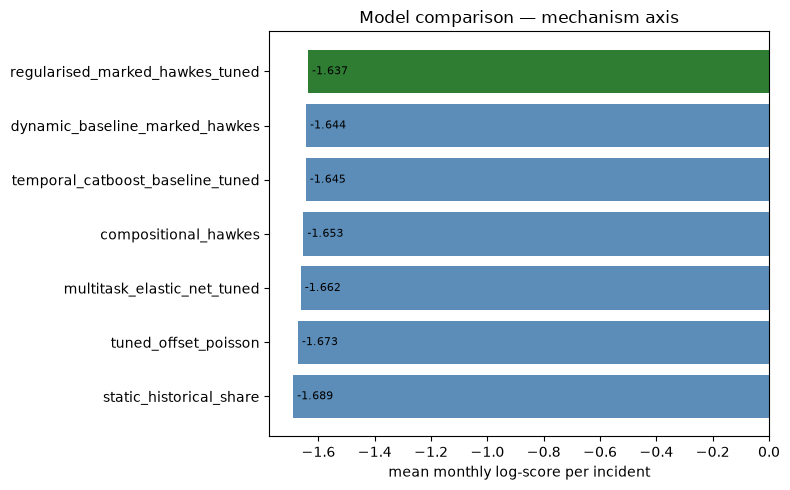

In [12]:
if "mean_log_score_per_incident" in table.columns:
    o = table.sort_values("mean_log_score_per_incident")
    fig, ax = plt.subplots(figsize=(8, 0.5*len(o)+1.5))
    colors = ["#2E7D32" if i==len(o)-1 else "#5B8DB8" for i in range(len(o))]
    ax.barh(o["model"], o["mean_log_score_per_incident"], color=colors)
    ax.set_xlabel("mean monthly log-score per incident")
    ax.set_title(f"Model comparison — {AXIS} axis")
    for i,(m,v) in enumerate(zip(o["model"], o["mean_log_score_per_incident"])):
        ax.text(v, i, f" {v:.3f}", va="center", ha="left" if v<0 else "right", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR / f"ranking_logscore_{AXIS}.png", dpi=130)
    plt.show()

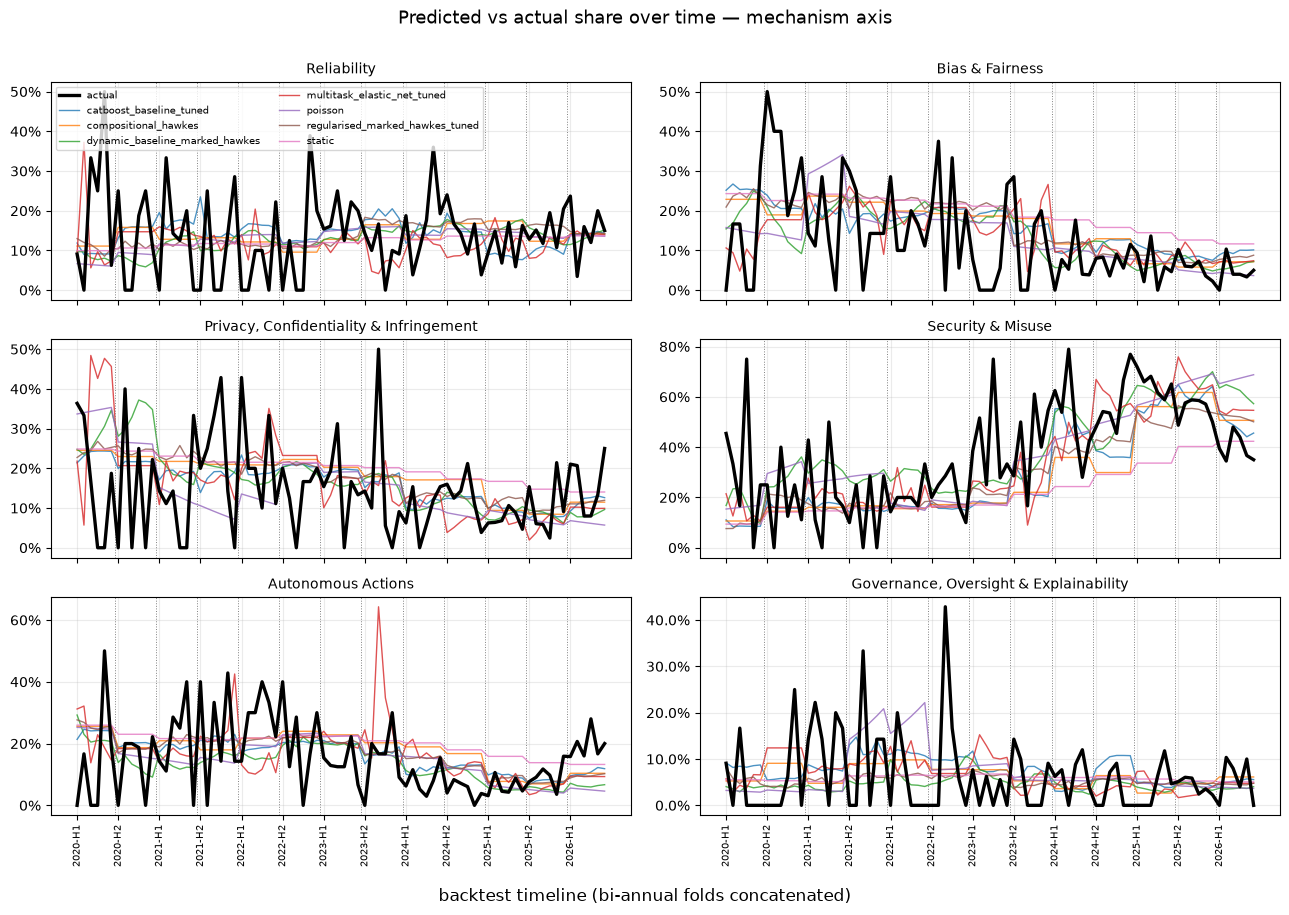

In [ ]:
# plot the continuous backtest timeline across all bi-annual folds
tl = (pred[["fold", PERIOD]].drop_duplicates()
        .sort_values(["fold", PERIOD]).reset_index(drop=True))
tl["idx"] = range(len(tl))
tmap = {(f, p): i for f, p, i in zip(tl["fold"], tl[PERIOD], tl["idx"])}
pred["idx"] = list(zip(pred["fold"], pred[PERIOD]))
pred["idx"] = pred["idx"].map(tmap)

cats = [c for c in ORDER if c in pred[CATEGORY].unique().tolist()]
ncat = len(cats)
ncols = 2
nrows = int(np.ceil(ncat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3*nrows), sharex=True)
axes = np.array(axes).reshape(-1)
cmap = plt.cm.tab10

for ai, cat in enumerate(cats):
    ax = axes[ai]
    sub = pred[pred[CATEGORY] == cat]
    act = (sub.groupby("idx")["actual_share"].mean())
    ax.plot(act.index, act.values, color="black", lw=2.4, label="actual", zorder=5)
    for mi, m in enumerate(models):
        ms = sub[sub.model == m].groupby("idx")["predicted_share"].mean()
        ax.plot(ms.index, ms.values, lw=1.0, alpha=0.8,
                color=cmap(mi % 10), label=m)
    ax.set_title(str(cat), fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(alpha=0.25)
for j in range(ncat, len(axes)): axes[j].axis("off")

fold_starts = tl.groupby("fold")["idx"].min().sort_values()
for ax in axes[:ncat]:
    for fs in fold_starts.values[1:]:
        ax.axvline(fs-0.5, color="grey", ls=":", lw=0.7)
for ax in axes[ncat-ncols:ncat]:
    ax.set_xticks(fold_starts.values)
    ax.set_xticklabels(fold_starts.index, rotation=90, fontsize=7)

axes[0].legend(fontsize=7, ncol=2, loc="upper left")
fig.suptitle(f"Predicted vs actual share over time — {AXIS} axis", y=1.005, fontsize=13)
fig.supxlabel("backtest timeline (bi-annual folds concatenated)")
plt.tight_layout()
plt.savefig(FIGDIR / f"share_over_time_{AXIS}.png", dpi=130, bbox_inches="tight")
plt.show()

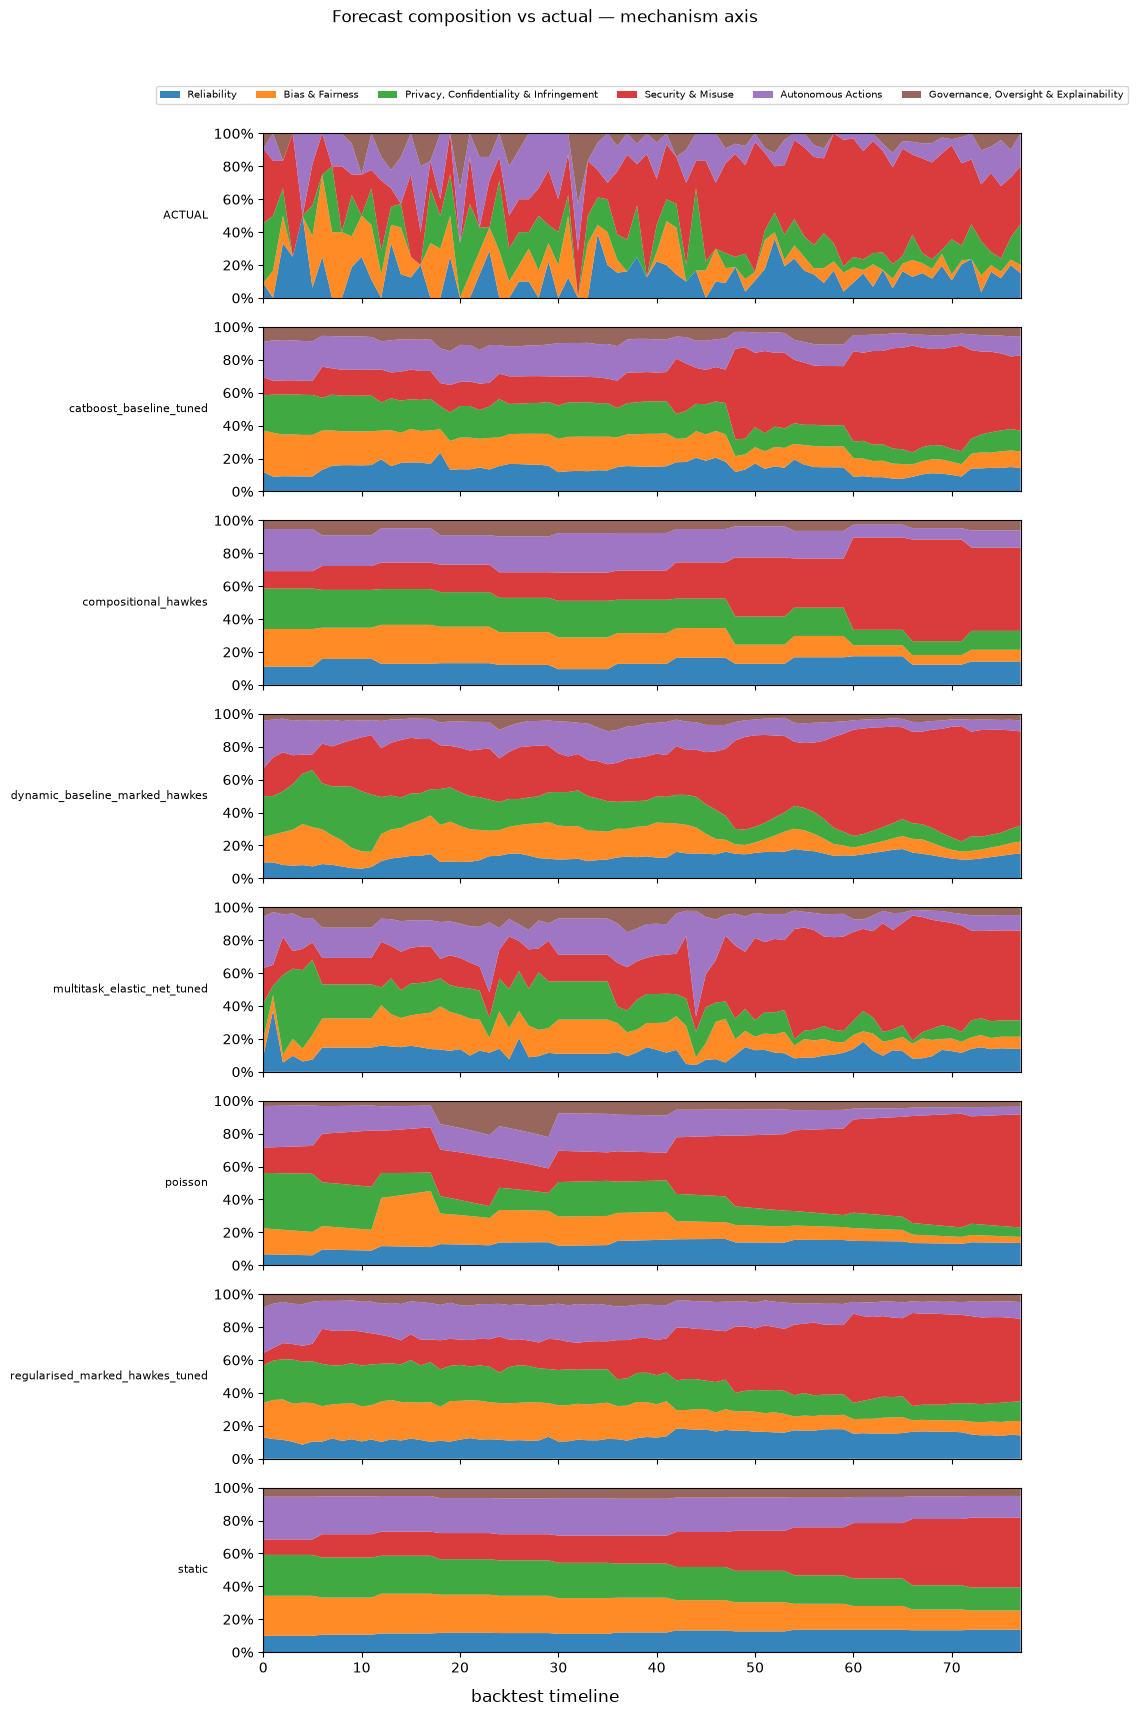

In [14]:
panels = ["actual"] + models
npan = len(panels)
fig, axes = plt.subplots(npan, 1, figsize=(11, 2.1*npan), sharex=True)
axes = np.array(axes).reshape(-1)
colors = {c: plt.cm.tab10(i % 10) for i, c in enumerate(cats)}

for pi, panel in enumerate(panels):
    ax = axes[pi]
    if panel == "actual":
        wide = (pred[pred.model == models[0]]
                  .pivot_table(index="idx", columns=CATEGORY,
                               values="actual_share", aggfunc="mean", observed=True))
        title = "ACTUAL"
    else:
        wide = (pred[pred.model == panel]
                  .pivot_table(index="idx", columns=CATEGORY,
                               values="predicted_share", aggfunc="mean", observed=True))
        title = panel
    wide = wide.reindex(columns=cats)
    ax.stackplot(wide.index, [wide[c].values for c in cats],
                 colors=[colors[c] for c in cats], alpha=0.9)
    ax.set_ylim(0, 1); ax.set_ylabel(title, fontsize=8, rotation=0, ha="right", va="center")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.margins(x=0)
axes[0].legend([str(c) for c in cats], fontsize=7, ncol=len(cats),
               loc="lower center", bbox_to_anchor=(0.5, 1.15))
fig.suptitle(f"Forecast composition vs actual — {AXIS} axis", y=1.02)
fig.supxlabel("backtest timeline")
plt.tight_layout()
plt.savefig(FIGDIR / f"composition_{AXIS}.png", dpi=130, bbox_inches="tight")
plt.show()

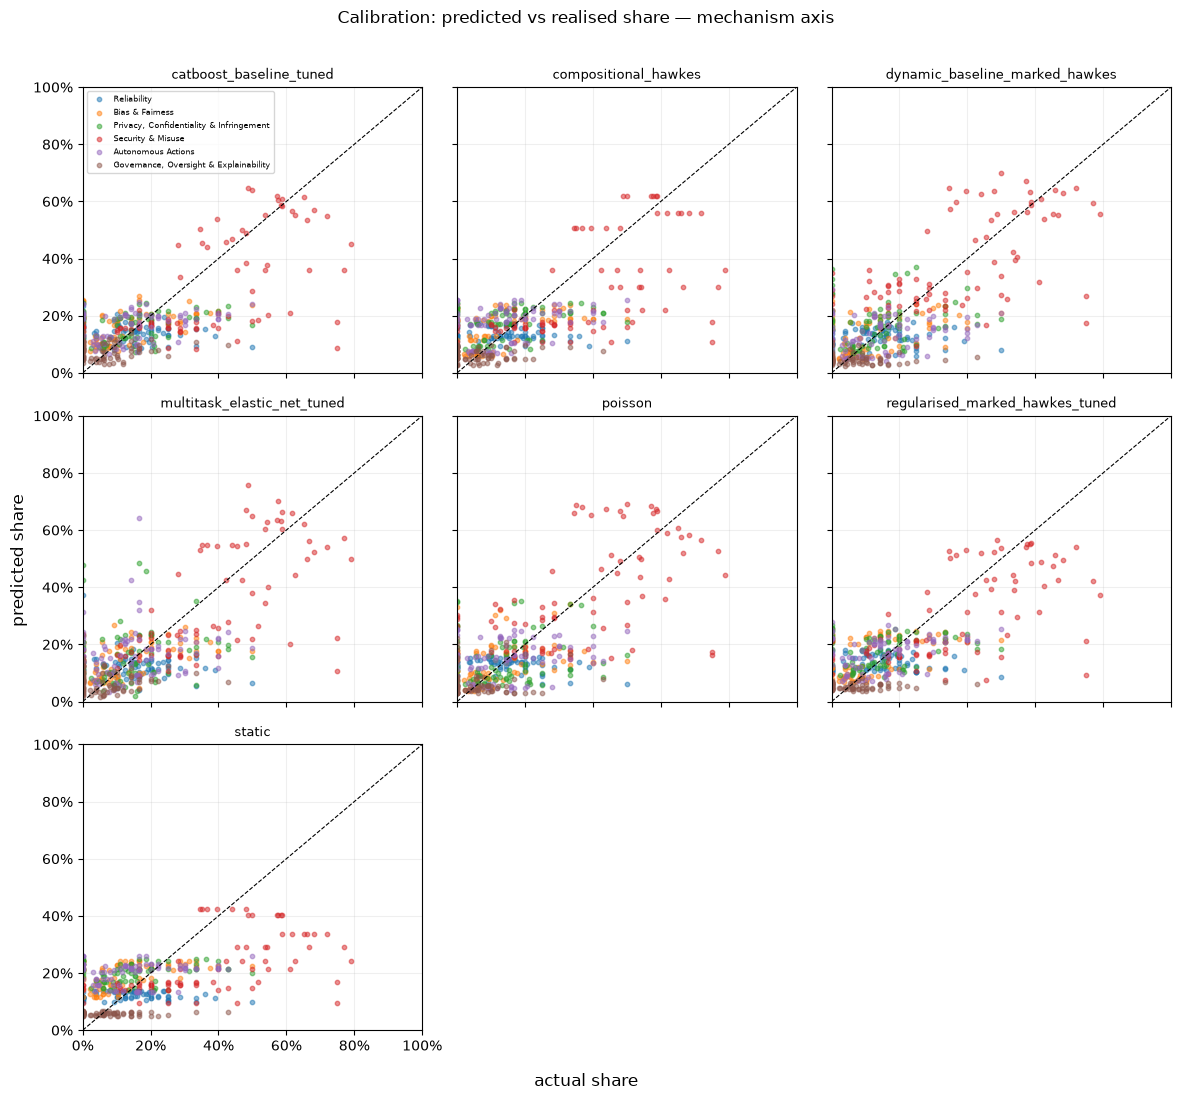

In [15]:
ncols = 3
nrows = int(np.ceil(len(models)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for mi, m in enumerate(models):
    ax = axes[mi]
    sub = pred[pred.model == m]
    for ci, c in enumerate(cats):
        cc = sub[sub[CATEGORY] == c]
        ax.scatter(cc["actual_share"], cc["predicted_share"],
                   s=10, alpha=0.5, color=plt.cm.tab10(ci % 10), label=str(c))
    lim = 1.0
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_title(m, fontsize=9)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(alpha=0.2)
for j in range(len(models), len(axes)): axes[j].axis("off")
axes[0].legend(fontsize=6, loc="upper left")
fig.suptitle(f"Calibration: predicted vs realised share — {AXIS} axis", y=1.01)
fig.supxlabel("actual share"); fig.supylabel("predicted share")
plt.tight_layout()
plt.savefig(FIGDIR / f"calibration_{AXIS}.png", dpi=130, bbox_inches="tight")
plt.show()

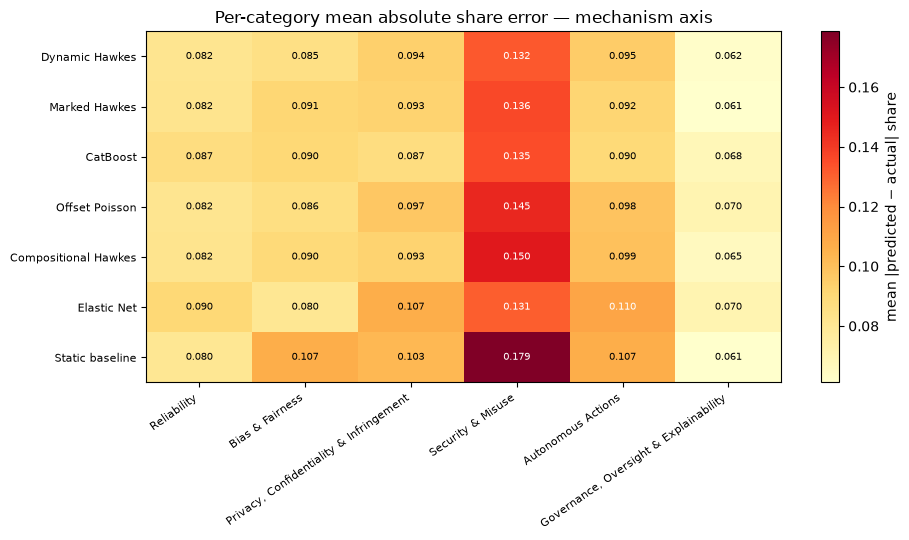

category,Reliability,Bias & Fairness,"Privacy, Confidentiality & Infringement",Security & Misuse,Autonomous Actions,"Governance, Oversight & Explainability"
disp,,,,,,
Dynamic Hawkes,0.0816,0.0851,0.0938,0.1322,0.0952,0.0622
Marked Hawkes,0.0819,0.0910,0.0927,0.1362,0.0915,0.0611
CatBoost,0.0870,0.0901,0.0872,0.1350,0.0897,0.0678
Offset Poisson,0.0815,0.0862,0.0970,0.1453,0.0984,0.0703
Compositional Hawkes,0.0818,0.0896,0.0926,0.1501,0.0994,0.0654
Elastic Net,0.0905,0.0801,0.1067,0.1307,0.1101,0.0701
Static baseline,0.0802,0.1069,0.1026,0.1787,0.1070,0.0615


In [ ]:
# ---- per-category error heatmap ----
DISP = {
    "static_historical_share": "Static baseline",
    "static": "Static baseline",
    "tuned_offset_poisson": "Offset Poisson", "poisson": "Offset Poisson",
    "multitask_elastic_net_tuned": "Elastic Net",
    "temporal_catboost_baseline_tuned": "CatBoost",
    "catboost_baseline_tuned": "CatBoost",
    "regularised_marked_hawkes_tuned": "Marked Hawkes",
    "dynamic_baseline_marked_hawkes": "Dynamic Hawkes",
    "compositional_hawkes": "Compositional Hawkes",
}

ph = pred[pred["model"] != "long"].copy()
ph["disp"] = ph["model"].map(lambda m: DISP.get(m, m))

err = (ph.assign(abs_err=(ph["predicted_share"] - ph["actual_share"]).abs())
          .groupby(["disp", CATEGORY], observed=True)["abs_err"].mean()
          .unstack(CATEGORY).reindex(columns=cats))
err = err.loc[err.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(1.1*len(cats)+3, 0.5*len(err)+2))
im = ax.imshow(err.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(cats)))
ax.set_xticklabels([str(c) for c in cats], rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(err))); ax.set_yticklabels(err.index, fontsize=8)
for i in range(err.shape[0]):
    for j in range(err.shape[1]):
        v = err.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7,
                    color="black" if v < np.nanmax(err.values)*0.6 else "white")
fig.colorbar(im, ax=ax, label="mean |predicted − actual| share")
ax.set_title(f"Per-category mean absolute share error — {AXIS} axis")
plt.tight_layout()
plt.savefig(FIGDIR / f"error_heatmap_{AXIS}.png", dpi=130, bbox_inches="tight")
plt.show()
display(err.style.format("{:.4f}").background_gradient(cmap="YlOrRd"))

In [ ]:

table.to_csv(OUT / f"model_comparison_table_{AXIS}.csv", index=False)
err.to_csv(OUT / f"model_category_error_{AXIS}.csv")
keep = ["model","fold",PERIOD,CATEGORY,"actual_count","actual_share","predicted_share"]
if len(paired):
    paired.to_csv(OUT / f"paired_vs_static_{AXIS}.csv", index=False)

print("Wrote to", OUT)
for f in [f"model_comparison_table_{AXIS}.csv", f"model_category_error_{AXIS}.csv",
          f"predictions_long_{AXIS}.csv", f"paired_vs_static_{AXIS}.csv"]:
    print("  ", f)
print("Figures in", FIGDIR)

Wrote to model_outputs
   model_comparison_table_mechanism.csv
   model_category_error_mechanism.csv
   predictions_long_mechanism.csv
   paired_vs_static_mechanism.csv
Figures in model_outputs\comparison_figures


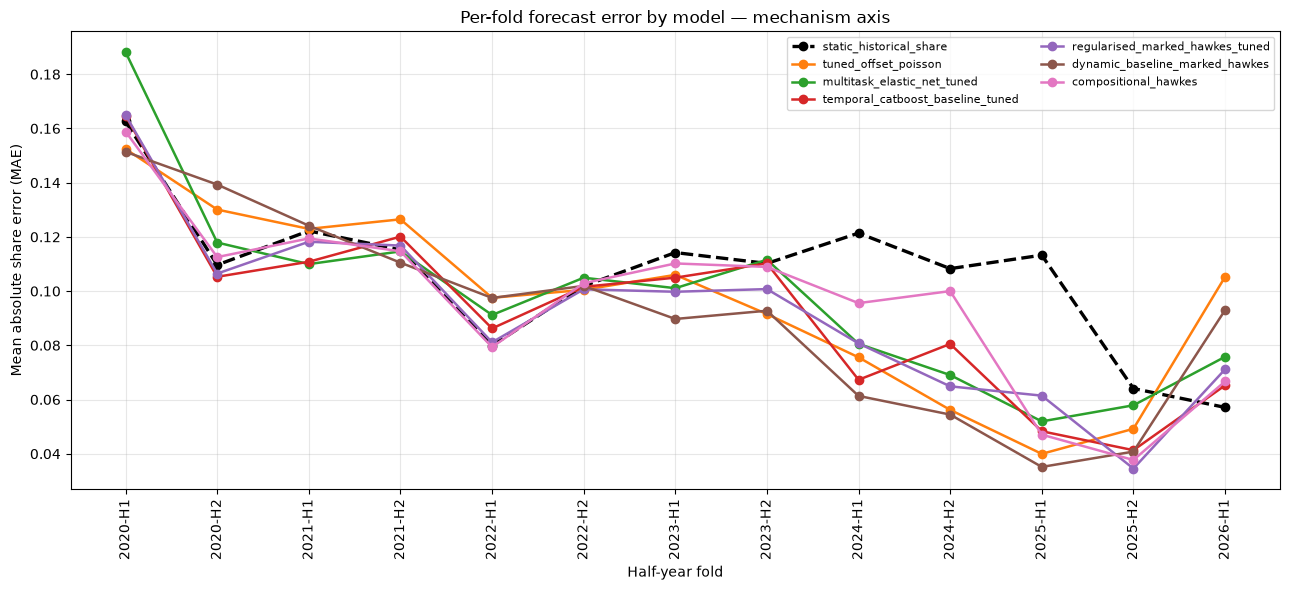

In [ ]:
# ---- per-fold performance: MAE by half-year fold, one line per model ----
import glob
from pathlib import Path
OUTPUT_DIR = Path("model_outputs")
FOLD_ORDER = [_ec.fold_label(y, h) for (y, h) in _ec.TEST_FOLDS]

byfold = {}
for f in glob.glob(str(OUTPUT_DIR / f"metrics_*_byfold_{AXIS}.csv")):
    d = pd.read_csv(f)
    if "fold" not in d.columns or "mae" not in d.columns:
        continue
    name = d["model"].iloc[0] if "model" in d.columns else \
           f.split("metrics_")[1].split(f"_byfold_{AXIS}")[0]
    byfold[name] = d.set_index("fold")["mae"].reindex(FOLD_ORDER)

order = [m for m in
         ["static_historical_share","tuned_offset_poisson","poisson",
          "multitask_elastic_net_tuned","temporal_catboost_baseline_tuned",
          "catboost_baseline_tuned","regularised_marked_hawkes_tuned",
          "dynamic_baseline_marked_hawkes","compositional_hawkes"]
         if m in byfold]
order += [m for m in byfold if m not in order] 
fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.tab10
for i, m in enumerate(order):
    y = byfold[m].values
    style = dict(lw=2.4, ls="--", color="black") if "static" in m else \
            dict(lw=1.8, color=cmap(i % 10))
    ax.plot(range(len(FOLD_ORDER)), y, marker="o", label=m, **style)

ax.set_xticks(range(len(FOLD_ORDER)))
ax.set_xticklabels(FOLD_ORDER, rotation=90)
ax.set_xlabel("Half-year fold")
ax.set_ylabel("Mean absolute share error (MAE)")
ax.set_title(f"Per-fold forecast error by model — {AXIS} axis")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGDIR / f"per_fold_mae_{AXIS}.png", dpi=140, bbox_inches="tight")
plt.show()

In [20]:
import numpy as np
MECH = ["Reliability","Bias & Fairness","Privacy","Security & Misuse",
        "Autonomous Actions","Governance"]

matrices = {
"Marked Hawkes": np.array([
 [0.192,0.025,0.000,0.171,0.087,0.057],[0.000,0.083,0.004,0.048,0.000,0.007],
 [0.170,0.033,0.081,0.057,0.113,0.142],[0.286,0.086,0.066,0.806,0.050,0.264],
 [0.186,0.000,0.092,0.028,0.103,0.189],[0.068,0.000,0.035,0.024,0.107,0.003]]),
"Dynamic Hawkes": np.array([
 [0.119,0.012,0.001,0.193,0.022,0.010],[0.001,0.094,0.001,0.053,0.001,0.012],
 [0.485,0.001,0.000,0.000,0.016,0.006],[0.019,0.087,0.051,0.878,0.001,0.007],
 [0.094,0.005,0.006,0.000,0.025,0.009],[0.013,0.002,0.007,0.006,0.018,0.001]]),
"Compositional Hawkes": np.array([
 [0.088,0.031,0.015,0.029,0.096,0.005],[0.051,0.008,0.079,0.096,0.085,0.079],
 [0.018,0.031,0.095,0.059,0.091,0.058],[0.037,0.036,0.031,0.067,0.086,0.074],
 [0.009,0.038,0.026,0.077,0.031,0.097],[0.053,0.067,0.078,0.031,0.062,0.013]]),
}
for name, K in matrices.items():
    out_inf, in_inf = K.sum(0), K.sum(1)
    net = out_inf - in_inf
    print(f"\n=== {name} | spectral radius {max(abs(np.linalg.eigvals(K))):.3f} ===")
    for i in np.argsort(net)[::-1]:
        role = "driver" if net[i] > 0 else "receiver"
        print(f"  {MECH[i]:20s} sends {out_inf[i]:.2f} receives {in_inf[i]:.2f} net {net[i]:+.2f} ({role})")


=== Marked Hawkes | spectral radius 0.918 ===
  Governance           sends 0.66 receives 0.24 net +0.43 (driver)
  Reliability          sends 0.90 receives 0.53 net +0.37 (driver)
  Bias & Fairness      sends 0.23 receives 0.14 net +0.08 (driver)
  Autonomous Actions   sends 0.46 receives 0.60 net -0.14 (receiver)
  Privacy              sends 0.28 receives 0.60 net -0.32 (receiver)
  Security & Misuse    sends 1.13 receives 1.56 net -0.42 (receiver)

=== Dynamic Hawkes | spectral radius 0.896 ===
  Reliability          sends 0.73 receives 0.36 net +0.37 (driver)
  Security & Misuse    sends 1.13 receives 1.04 net +0.09 (driver)
  Bias & Fairness      sends 0.20 receives 0.16 net +0.04 (driver)
  Governance           sends 0.04 receives 0.05 net -0.00 (receiver)
  Autonomous Actions   sends 0.08 receives 0.14 net -0.06 (receiver)
  Privacy              sends 0.07 receives 0.51 net -0.44 (receiver)

=== Compositional Hawkes | spectral radius 0.318 ===
  Autonomous Actions   sends 0.45 r